In [37]:
from collections import Counter
import math
import matplotlib.pyplot as plt

def distance(point1, point2):
    # return sum(abs(x - y) for x, y in zip(point1, point2))
    return math.sqrt(sum((x - y) ** 2 for x, y in zip(point1, point2)))

def majority_votes(k_nearest_labels):
    if not k_nearest_labels:
        raise ValueError("Cannot determine majority of an empty label list.")

    vote_counts = Counter(k_nearest_labels)
    winner, winner_count = vote_counts.most_common(1)[0]

    num_winners = len([count for count in vote_counts.values() if count == winner_count])

    if num_winners == 1:
        return winner
    else:
        return majority_votes(k_nearest_labels[:-1])

def knn_classify(k, labeled_points, new_point):
    by_distance = sorted(labeled_points, key=lambda item: distance(item[0], new_point))

    k_nearest_labels = [label for _, label in by_distance[:k]]

    return majority_votes(k_nearest_labels)


In [38]:
cities = [
    ([-122.33, 47.61], "Python"),  # Seattle
    ([-122.08, 37.38], "Python"),  # Mountain View (Silicon Valley)
    ([-121.89, 37.33], "Python"),  # San Jose
    ([-118.24, 34.05], "Python"),  # Los Angeles
    ([-122.68, 45.52], "Python"),  # Portland
    ([-111.89, 40.76], "Python"),  # Salt Lake City
    ([-96.80, 32.78], "Java"),     # Dallas
    ([-95.37, 29.76], "Java"),     # Houston
    ([-97.74, 30.27], "Java"),     # Austin
    ([-84.39, 33.75], "Java"),     # Atlanta
    ([-90.08, 29.95], "Java"),     # New Orleans
    ([-80.84, 35.23], "Java"),     # Charlotte
    ([-89.40, 43.07], "R"),        # Madison (Academic Hub)
    ([-71.06, 42.36], "R"),        # Boston / Cambridge (Harvard/MIT)
    ([-74.00, 40.71], "R"),        # New York City (Finance/Data Science)
    ([-77.04, 38.90], "R"),        # Washington D.C. (Government/Stats)
    ([-87.63, 41.88], "R"),        # Chicago
    ([-104.99, 39.74], "R"),       # Denver
    ([-122.41, 37.77], "Python"),  # San Francisco, CA
    ([-117.16, 32.71], "Python"),  # San Diego, CA (Biotech AI / Defense)
    ([-106.65, 35.08], "Python"),  # Albuquerque, NM (National Labs / Research)
    ([-112.07, 33.44], "Python"),  # Phoenix, AZ (Semi-conductors & Autonomous Tech)
    ([-114.07, 51.04], "Python"),  # Calgary, AB (Energy Systems Tech)
    ([-123.12, 49.28], "Python"),  # Vancouver, BC (Cascadia Tech Extension)
    ([-106.34, 56.13], "Python"),  # Saskatchewan, Canada (Northern Tech outlier)
    ([-86.15, 39.76], "Java"),     # Indianapolis, IN (Enterprise SaaS hub)
    ([-82.99, 39.96], "Java"),     # Columbus, OH (Insurance & Corporate Enterprise)
    ([-93.26, 44.97], "Java"),     # Minneapolis, MN (Retail Corp Headquarters)
    ([-94.57, 39.09], "Java"),     # Kansas City, MO (Telecom & Logistics)
    ([-79.38, 43.65], "Java"),     # Toronto, ON (Massive Financial / Banking sector)
    ([-81.65, 30.33], "Java"),     # Jacksonville, FL (Logistics & Backend Ops)
    ([-98.49, 29.42], "Java"),     # San Antonio, TX (Cybersecurity & Federal Enterprise)
    ([-78.89, 35.99], "R"),        # Durham/Raleigh, NC (Research Triangle Park)
    ([-75.16, 39.95], "R"),        # Philadelphia, PA (Healthcare & Pharma Data)
    ([-79.99, 40.44], "R"),        # Pittsburgh, PA (Carnegie Mellon Data Science)
    ([-83.04, 42.33], "R"),        # Detroit, MI (Automotive Systems Engineering)
    ([-73.56, 45.50], "R"),        # Montreal, QC (Major Academic AI & Statistical Labs)
    ([-71.20, 46.81], "R")         # Quebec City, QC (Government Statistics)
]

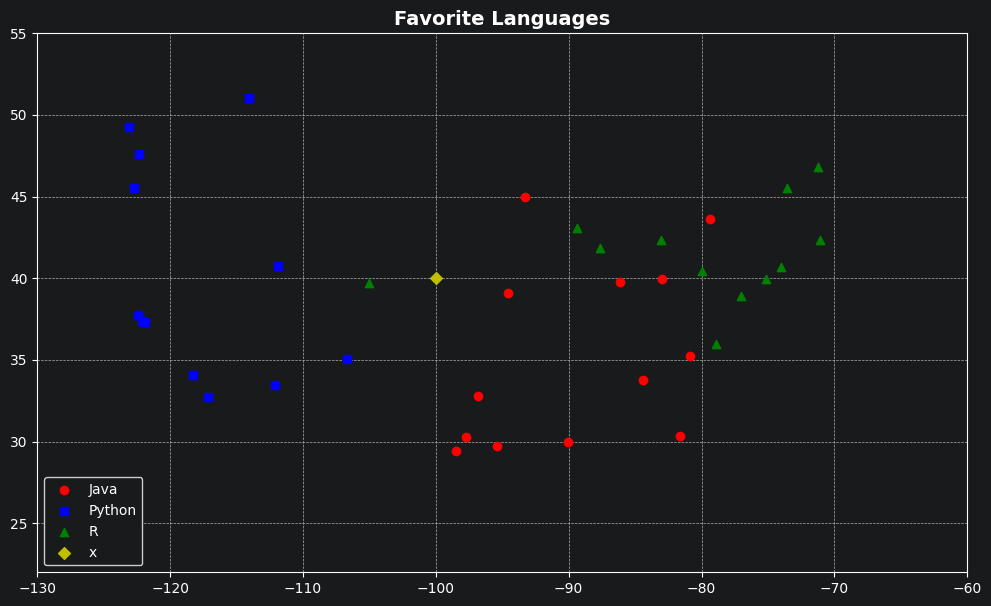

In [39]:
plt.figure(figsize=(12, 7))
plots = {"Java" : ([],[]), "Python" : ([],[]), "R" : ([],[])}
markers = {"Java": "o", "Python" : "s", "R" : "^"}
colors = {"Java": "r", "Python" : "b", "R" : "g"}

for (longitude, latitude), language in cities:
    plots[language][0].append(longitude)
    plots[language][1].append(latitude)

for language, (x,y) in plots.items():
    plt.scatter(x,y, color=colors[language], marker=markers[language], label=language, zorder=10)

plt.scatter(-100.0, 40.0, color="y", marker="D", label="x", zorder=10)

plt.legend(loc="lower left", framealpha=1)
plt.axis((-130.0,-60.0,22.0,55.0))
plt.title("Favorite Languages", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=1)
plt.show()

In [40]:
for k in [1, 3, 5, 7]:
    num_correct = 0

    for city in cities:
        location, actual_language = city
        other_cities = [other_city for other_city in cities if other_city != city]

        predicted_language = knn_classify(k, other_cities, location)

        if predicted_language == actual_language:
            num_correct += 1

    print (k, "neighbor[s] :", num_correct, "correct out of", len(cities))

1 neighbor[s] : 29 correct out of 38
3 neighbor[s] : 30 correct out of 38
5 neighbor[s] : 30 correct out of 38
7 neighbor[s] : 29 correct out of 38


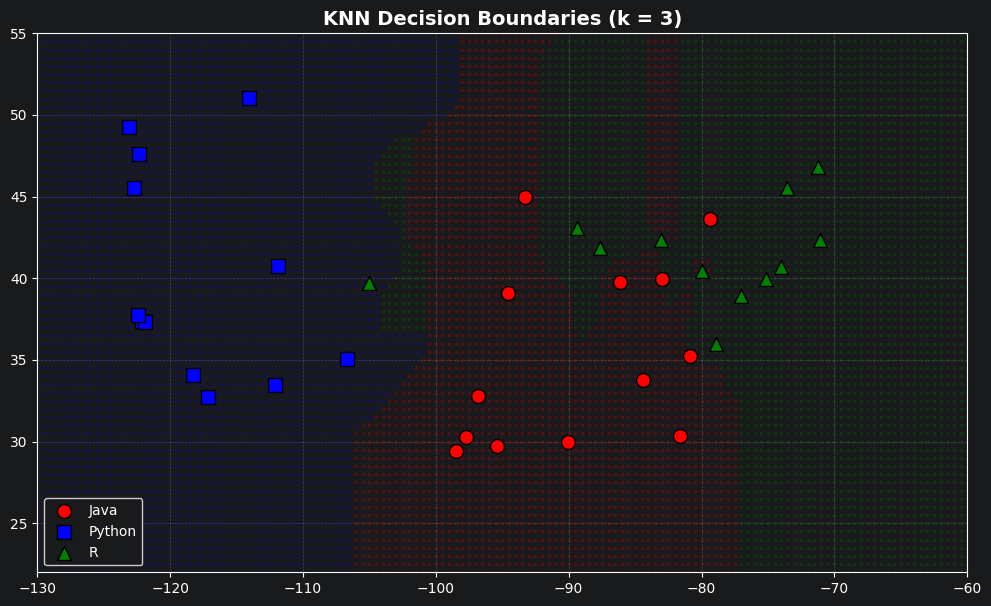

In [41]:
plt.figure(figsize=(12, 7))

grid_plots = {"Java": ([], []), "Python": ([], []), "R": ([], [])}
k = 3

longitudes = [x * 0.5 for x in range(-260, -119)] # -130.0 to -60.0
latitudes = [y * 0.5 for y in range(44, 111)]     # 22.0 to 55.0

for longitude in longitudes:
    for latitude in latitudes:
        predicted_language = knn_classify(k, cities, [longitude, latitude])
        grid_plots[predicted_language][0].append(longitude)
        grid_plots[predicted_language][1].append(latitude)

for language, (x, y) in grid_plots.items():
    plt.scatter(x, y, color=colors[language], marker='.', s=15, alpha=0.15, zorder=1)

original_plots = {"Java": ([], []), "Python": ([], []), "R": ([], [])}
for (long, lat), language in cities:
    original_plots[language][0].append(long)
    original_plots[language][1].append(lat)

for language, (x, y) in original_plots.items():
    plt.scatter(x, y, color=colors[language], marker=markers[language],
                s=100, edgecolor='black', label=language, zorder=10)

plt.legend(loc="lower left", framealpha=1)
plt.axis((-130.0,-60.0,22.0,55.0))
plt.title(f"KNN Decision Boundaries (k = {k})", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [42]:
knn_classify(k=15,labeled_points=cities,new_point=[-100.0,40.0])

'Java'